In [2]:
import sys
import os

# Add the src directory to sys.path
sys.path.append(os.path.abspath("../src"))

In [4]:
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn, Tensor
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset

from abstractions.dsl.abstraction import Abstraction
from abstractions.dsl.instantiation import instantiate
from abstractions.dsl.core import Shape
from abstractions.dsl.nodes import Rect, Move, SymTrans, SymRef, Union

from abstractions.primitives.visualization import show_boxes
from abstractions.data.toy import random_chairs_1, random_chairs_2, random_tables_1

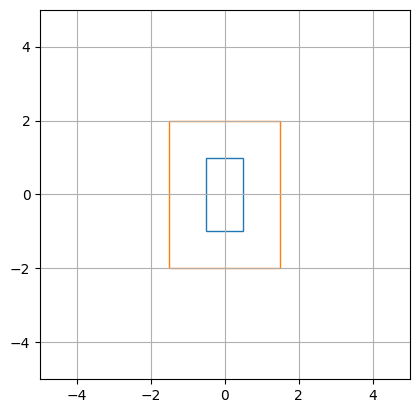

In [5]:

test_shape = instantiate([Union, Rect, float, float, Rect, float, float], [1, 2, 3, 4])
show_boxes(test_shape.get_box_list(), limits=(-5, 5))

Union(
        Rect(
        0.500,
        0.125
    ),
        SymRef(
            Move(
                Rect(
                0.125,
                0.500
            ),
            0.188,
            -0.312
        ),
        x
    )
)


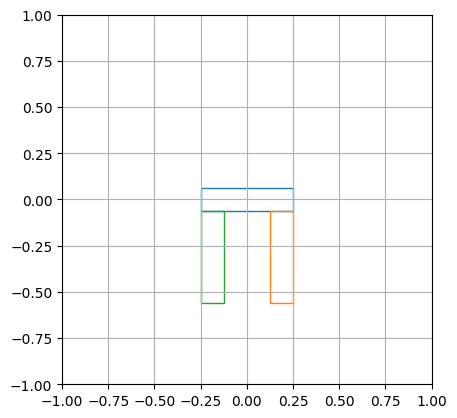

In [6]:
chair = random_tables_1(1)[0]

print(chair)

show_boxes(chair.get_box_list())

In [7]:

# dataset = random_shapes(1024, max_nodes=32)
dataset = random_chairs_1(512) + random_chairs_2(512) + random_tables_1(512)


In [8]:
def add(structures1, structures2):

    for key in structures2.keys():
        structures1[key] += structures2[key]

    return structures1


In [9]:
def get_singletons(shapes: Shape | list[Shape]):
    if isinstance(shapes, list):
        singletons = defaultdict(list)

        for shape in shapes:
            singletons = add(singletons, get_singletons(shape))

        return singletons

    type, parameters = shapes.param_tuple()
    type_str = type.__name__
    current_structures = defaultdict(list)
    current_structures[type_str].append(parameters)

    if isinstance(shapes, Move) or isinstance(shapes, SymTrans) or isinstance(shapes, SymRef):
        current_structures = add(get_singletons(shapes.children[0]), current_structures)
    elif isinstance(shapes, Union):
        current_structures = add(get_singletons(shapes.children[0]), current_structures)
        current_structures = add(get_singletons(shapes.children[1]), current_structures)

    return current_structures



In [10]:
def get_pairs(shapes: Shape | list[Shape]):
    if isinstance(shapes, list):
        pairs = defaultdict(list)

        for shape in shapes:
            pairs = add(pairs, get_pairs(shape))

        return pairs

    if isinstance(shapes, Move) or isinstance(shapes, SymTrans) or isinstance(shapes, SymRef):
        return get_pairs(shapes.children[0])
    elif isinstance(shapes, Union):
        type, (child1, child2) = shapes.param_tuple()
        type1, parameters1 = child1.param_tuple()
        type2, parameters2 = child2.param_tuple()
        type_str = f"{type.__name__}({type1.__name__}, {type2.__name__})"
        current_structures = defaultdict(list)
        current_structures[type_str].append(parameters1 + parameters2)
        current_structures = add(get_pairs(shapes.children[0]), current_structures)
        current_structures = add(get_pairs(shapes.children[1]), current_structures)
        return current_structures
    else:
        return defaultdict(list)



In [11]:
singletons = get_singletons(dataset)
pairs = get_pairs(dataset)
structures = add(singletons, pairs)

for key, instances in structures.items():
    print(key, len(instances), instances[0])


Rect 4608 (0.125, 0.9)
Move 3072 (<abstractions.dsl.nodes.Rect object at 0x1330993d0>, 0.3625, -0.48750000000000004)
SymRef 1024 (<abstractions.dsl.nodes.Move object at 0x1330b4c80>, 'x')
Union 3072 (<abstractions.dsl.nodes.Move object at 0x1330e1700>, <abstractions.dsl.nodes.Rect object at 0x1331294f0>)
Union(Move, Rect) 1024 (<abstractions.dsl.nodes.Rect object at 0x1330b7500>, -0.32499999999999996, 0.32499999999999996, 0.85, 0.07500000000000001)
Union(Union, SymRef) 512 (<abstractions.dsl.nodes.Move object at 0x1330e1700>, <abstractions.dsl.nodes.Rect object at 0x1331294f0>, <abstractions.dsl.nodes.Move object at 0x1330b4c80>, 'x')
Union(Move, Move) 512 (<abstractions.dsl.nodes.Rect object at 0x1330b6990>, 0.0, -0.3625, <abstractions.dsl.nodes.Rect object at 0x1337ac8f0>, 0.0, -0.7)
Union(Union, Union) 512 (<abstractions.dsl.nodes.Move object at 0x1337aca40>, <abstractions.dsl.nodes.Rect object at 0x1337acaa0>, <abstractions.dsl.nodes.Move object at 0x1337ac890>, <abstractions.dsl.n

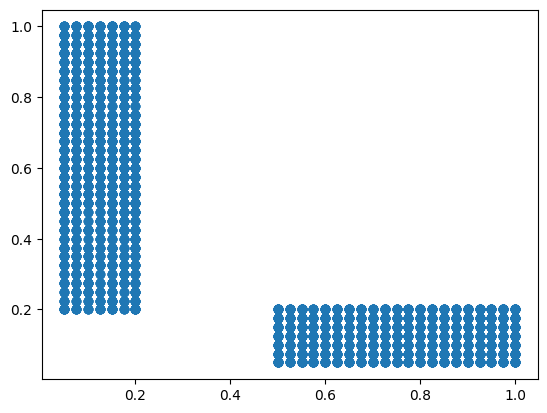

In [12]:

plt.figure()
plt.scatter([s[0] for s in structures["Rect"]], [s[1] for s in structures["Rect"]])
plt.show()


In [13]:
# for each type of structure, train a very small MLP with n inputs to predict the parameters
# if a low loss can be achieved with an n smaller than the number of parameters, then a new abstraction has been found

class MLP(nn.Module):
    def __init__(self, input_dim: int, output_dim: int):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.linear_1 = nn.Linear(input_dim, input_dim)
        self.activation = nn.ReLU()
        self.linear_2 = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        x = self.linear_1(x)
        x = self.activation(x)
        x = self.linear_2(x)
        return x



In [14]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.activation = nn.ReLU()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            self.activation,
            nn.Linear(32, 32),
            self.activation,
            nn.Linear(32, hidden_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            self.activation,
            nn.Linear(32, 32),
            self.activation,
            nn.Linear(32, input_dim)
        )

    def forward(self, x):
        encoding = self.encoder(x)
        reconstruction = self.decoder(encoding)
        return encoding, reconstruction



In [15]:

def prepare_mlp_train_data(parameters, output_index):
    tensor = torch.tensor(parameters).swapaxes(0, 1)
    input_data = tensor[:, tuple([i for i in range(tensor.shape[1]) if i != output_index])]
    output_data = tensor[:, (output_index, )]
    train_data = TensorDataset(input_data, output_data)
    train_dl = DataLoader(train_data, batch_size=64, shuffle=True)
    return train_dl

In [16]:
def prepare_autoencoder_train_data(parameters, mask):
    tensor = torch.tensor(parameters).swapaxes(0, 1)
    train_data = TensorDataset(tensor[mask, :])
    train_dl = DataLoader(train_data, batch_size=64, shuffle=True)
    return train_dl


In [17]:
def is_well_explained(parameters: Tensor, model: Autoencoder, threshold: float) -> Tensor:
    # parameters.shape = (batch_size, num_parameters)
    model.eval()

    with torch.no_grad():
        encodings, reconstructions = model(parameters)
        error, _ = torch.max(torch.abs(reconstructions - parameters), dim=-1)
        well_explained = error < threshold

    return well_explained


In [18]:

def find_abstractions(structures, retrain_iterations=2, error_threshold=0.01):
    losses = defaultdict(list)
    models = {}

    for name, parameters in structures.items():
        # for now, only consider float parameters
        valid_indices = [i for i in range(len(parameters[0])) if isinstance(parameters[0][i], float)]
        num_float_parameters = len(valid_indices)

        if num_float_parameters <= 0:
            continue

        float_parameters = [[p[valid_index] for p in parameters] for valid_index in valid_indices]
        well_explained = torch.ones(len(float_parameters[0]), dtype=torch.bool)

        for i in range(retrain_iterations):
            losses[name].append([])
            train_dl = prepare_autoencoder_train_data(float_parameters, mask=well_explained)
            model = Autoencoder(num_float_parameters, num_float_parameters - 1)
            optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=0.05)
            loss_fn = lambda pred, target: torch.mean(torch.max(torch.abs(pred - target), dim=-1)[0], dim=0)
            epochs = 100
            model.train()
            print(f"Iteration {i+1}/{retrain_iterations}: training model for {name} on {len(train_dl.dataset)} structures.")

            for epoch in range(epochs):
                running_train_loss = 0.0

                for x in train_dl:
                    x = x[0]
                    optimizer.zero_grad()
                    encoding, x_rec = model(x)
                    loss = loss_fn(x_rec, x)
                    loss.backward()
                    optimizer.step()
                    running_train_loss += loss.item()

                epoch_train_loss = running_train_loss / len(train_dl)
                losses[name][i].append(epoch_train_loss)
                # print(f"{name}, P{output_index}, Epoch {epoch + 1}/{epochs}, Train Loss: {epoch_train_loss:.3f}")

            well_explained = is_well_explained(torch.tensor(float_parameters).swapaxes(0, 1), model, threshold=error_threshold)

            if well_explained.sum() <= 0:
                # fix for debugging
                # if no structures are explained well, just train on the first one
                well_explained[0] = True

        models[name] = model
        print(f"Trained model for {name}. Final train loss: {losses[name][-1][-1]}")

    return models, losses


In [19]:
models, losses = find_abstractions(structures, retrain_iterations=4, error_threshold=0.01)


Iteration 1/4: training model for Rect on 4608 structures.
Iteration 2/4: training model for Rect on 473 structures.
Iteration 3/4: training model for Rect on 475 structures.
Iteration 4/4: training model for Rect on 549 structures.
Trained model for Rect. Final train loss: 0.007135246155990494
Iteration 1/4: training model for Move on 3072 structures.
Iteration 2/4: training model for Move on 1193 structures.
Iteration 3/4: training model for Move on 1126 structures.
Iteration 4/4: training model for Move on 1114 structures.
Trained model for Move. Final train loss: 0.003956318587168223
Iteration 1/4: training model for Union(Move, Rect) on 1024 structures.
Iteration 2/4: training model for Union(Move, Rect) on 30 structures.
Iteration 3/4: training model for Union(Move, Rect) on 1 structures.
Iteration 4/4: training model for Union(Move, Rect) on 1 structures.
Trained model for Union(Move, Rect). Final train loss: 0.012830086052417755
Iteration 1/4: training model for Union(Move, Mov

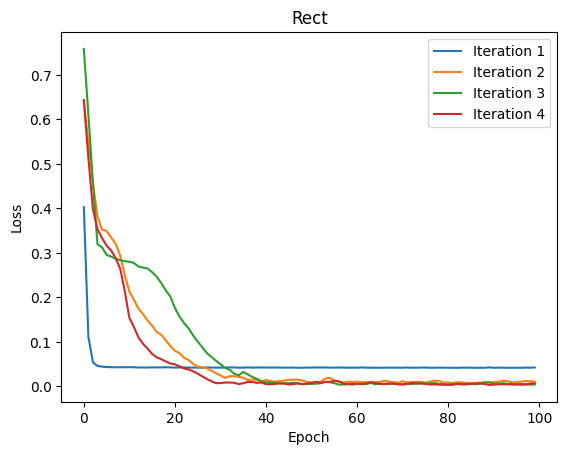

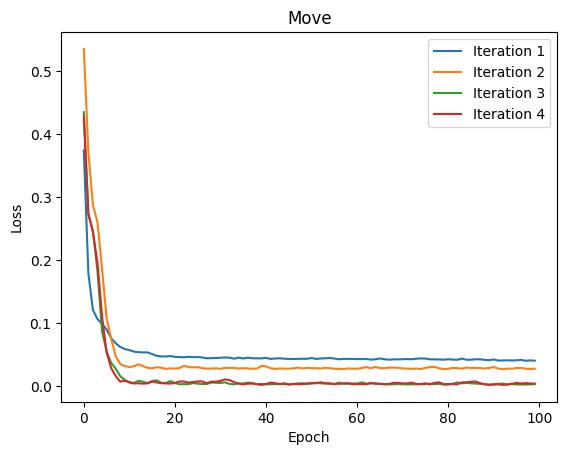

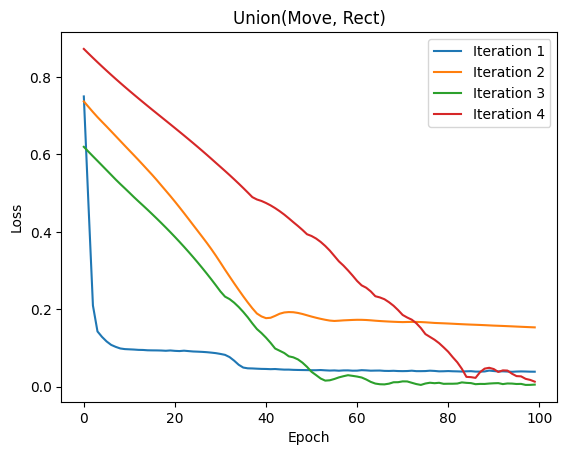

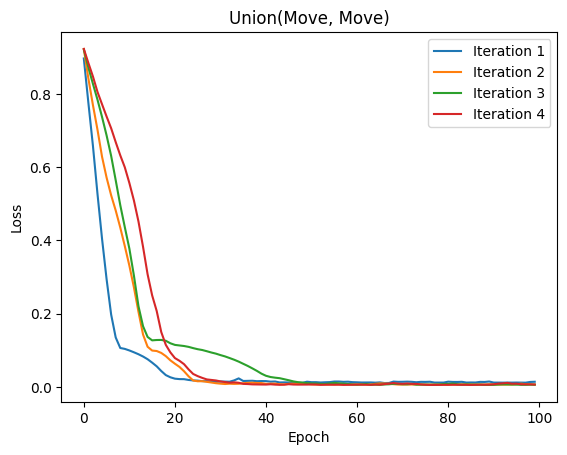

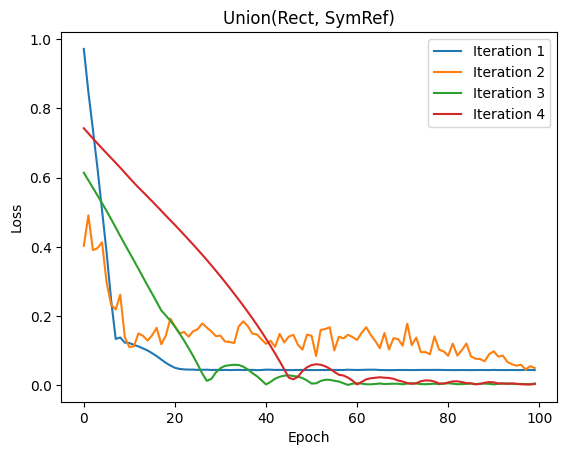

In [20]:

for structure_name, loss_list in losses.items():
    plt.figure()

    for i in range(len(loss_list)):
        plt.plot(loss_list[i], label=f"Iteration {i+1}")

    plt.legend()
    plt.title(structure_name)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

plt.show()


Rect (0.125, 0.9)
Move (<abstractions.dsl.nodes.Rect object at 0x1330993d0>, 0.3625, -0.48750000000000004)
Union(Move, Rect) (<abstractions.dsl.nodes.Rect object at 0x1330b7500>, -0.32499999999999996, 0.32499999999999996, 0.85, 0.07500000000000001)
Union(Move, Move) (<abstractions.dsl.nodes.Rect object at 0x1330b6990>, 0.0, -0.3625, <abstractions.dsl.nodes.Rect object at 0x1337ac8f0>, 0.0, -0.7)
Union(Rect, SymRef) (1.0, 0.05, <abstractions.dsl.nodes.Move object at 0x1340bb020>, 'x')


/var/folders/zb/9bmh3s9s3q5_mlv24by4t5x00000gn/T/ipykernel_20549/1217302645.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


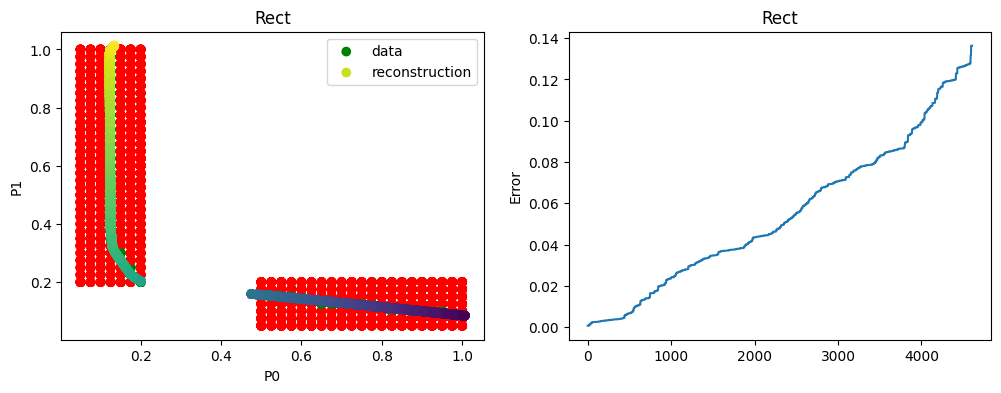

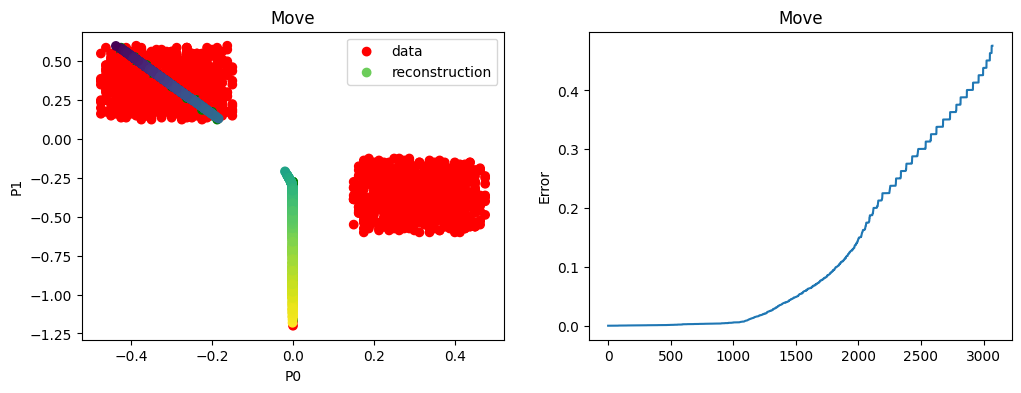

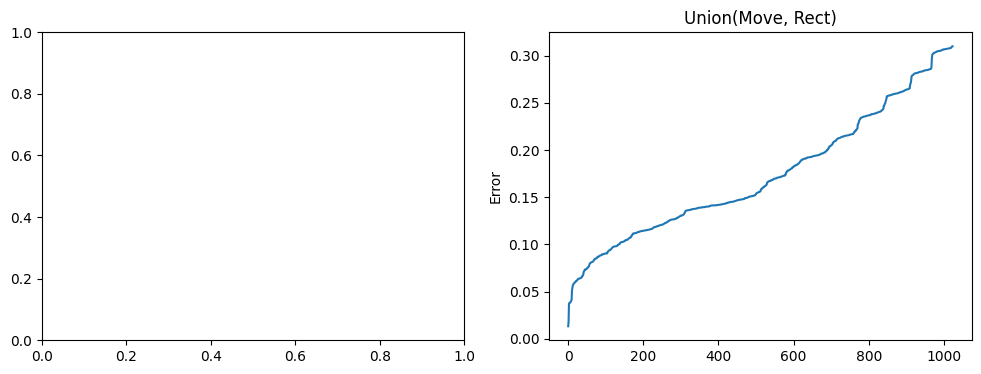

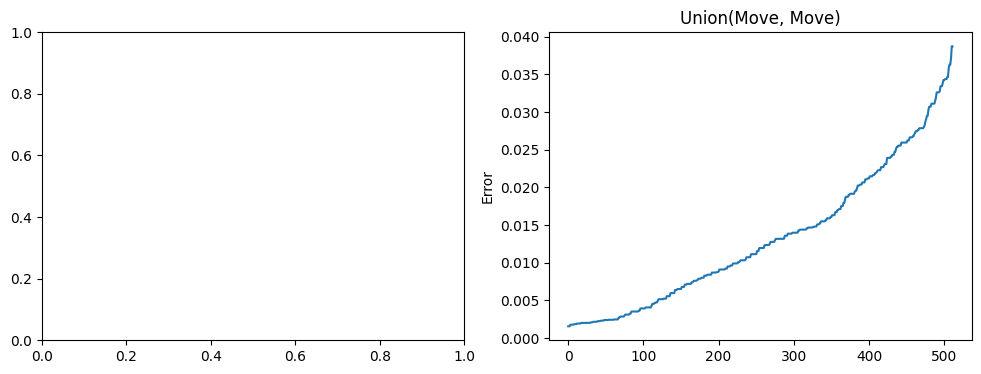

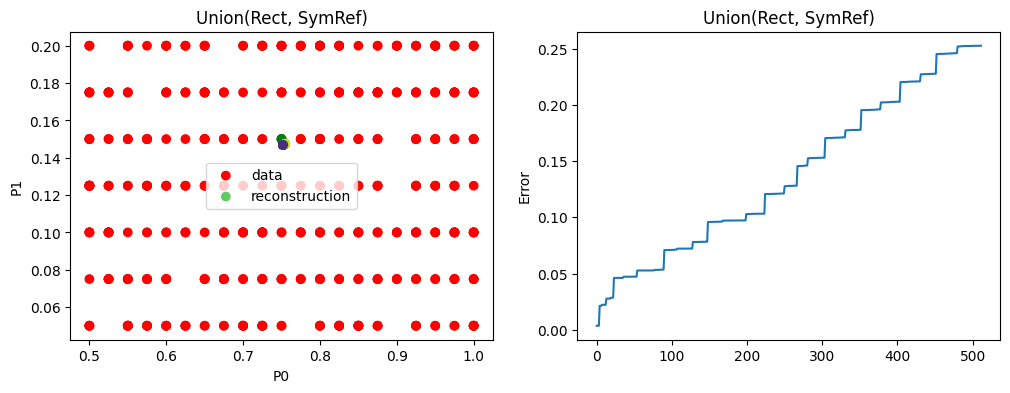

In [21]:

for structure_name, model in models.items():
    # for now, only consider float parameters
    parameters = structures[structure_name]
    print(structure_name, parameters[0])
    valid_indices = [i for i in range(len(parameters[0])) if isinstance(parameters[0][i], float)]
    num_float_parameters = len(valid_indices)

    if num_float_parameters <= 0:
        break

    float_parameters = [[p[valid_index] for p in parameters] for valid_index in valid_indices]
    data = torch.tensor(float_parameters).swapaxes(0, 1)

    model.eval()
    encodings, reconstructions = model(data)
    error, _ = torch.max(torch.abs(reconstructions - data), dim=-1)
    well_explained = error < 0.01
    encodings = encodings.detach().cpu().numpy()
    reconstructions = reconstructions.detach().cpu().numpy()
    error = error.detach().cpu().numpy()
    well_explained = well_explained.detach().cpu().numpy()

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    if data.shape[1] == 2:
        colors = ["green" if w else "red" for w in well_explained]
        ax[0].scatter(data[:, 0], data[:, 1], label="data", c=colors)
        ax[0].scatter(reconstructions[:, 0], reconstructions[:, 1], c=encodings, label="reconstruction")
        ax[0].legend()
        ax[0].set_title(structure_name)
        ax[0].set_xlabel("P0")
        ax[0].set_ylabel("P1")

    sorted_errors = np.sort(error)
    ax[1].plot(sorted_errors)
    ax[1].set_title(structure_name)
    ax[1].set_ylabel("Error")

    fig.show()


In [22]:

def integrate_abstractions(shape: list[Shape] | Shape, models: dict[str, Autoencoder], error_threshold: float) -> list[Shape] | Shape:
    if isinstance(shape, list):
        return [integrate_abstractions(s, models, error_threshold) for s in shape]

    if isinstance(shape, Union):
        # check pairs
        parent_type, (child1, child2) = shape.param_tuple()
        type1, parameters1 = child1.param_tuple()
        type2, parameters2 = child2.param_tuple()
        type_str = f"{parent_type.__name__}({type1.__name__}, {type2.__name__})"
        all_parameters = list(parameters1) + list(parameters2)
        float_parameters = [p for p in all_parameters if isinstance(p, float)]
        other_parameters = [p for p in all_parameters if isinstance(p, int) or isinstance(p, str) or isinstance(p, Shape)]

        if len(float_parameters) > 0 and type_str in models:
            # check if the appropriate abstraction fits well
            model_input = torch.tensor(float_parameters)[None, :]
            encoding, reconstruction = models[type_str](model_input)
            encoding = encoding[0, :]
            reconstruction = reconstruction[0, :]
            error, _ = torch.max(torch.abs(reconstruction - model_input), dim=-1)
            fits_well = error.item() < error_threshold
        else:
            # if there are no float parameters or there is no model for the current subtree, there is no abstraction that can be integrated
            fits_well = False
            encoding = None

        if fits_well:
            # integrate abstraction
            # the children of the abstraction have to be declared as "Shape" and not their specific type, so the instantiate function does not try to instantiate them further
            type_list = [parent_type, type1] + [Shape if isinstance(p, Shape) else type(p) for p in parameters1] + [type2] + [Shape if isinstance(p, Shape) else type(p) for p in parameters2]
            new_shape = Abstraction(type_list, encoding.tolist(), other_parameters, models[type_str])
        else:
            # dont integrate abstraction
            new_shape = Union(child1, child2)

        # continue integrating abstractions in children
        for i in range(len(new_shape.children)):
            new_shape.children[i] = integrate_abstractions(new_shape.children[i], models, error_threshold)

        return new_shape
    else:
        # check singletons
        parent_type, parameters = shape.param_tuple()
        type_str = type.__name__
        float_parameters = [p for p in parameters if isinstance(p, float)]
        other_parameters = [p for p in parameters if isinstance(p, int) or isinstance(p, str) or isinstance(p, Shape)]

        if len(float_parameters) > 0 and type_str in models:
            # check if the appropriate abstraction fits well
            model_input = torch.tensor(float_parameters)[None, :]
            encoding, reconstruction = models[type_str](model_input)
            encoding = encoding[0, :]
            reconstruction = reconstruction[0, :]
            error, _ = torch.max(torch.abs(reconstruction - model_input), dim=-1)
            fits_well = error.item() < error_threshold
        else:
            # if there are no float parameters or there is no model for the current subtree, there is no abstraction that can be integrated
            fits_well = False
            encoding = None

        if fits_well:
            # integrate abstraction
            # the children of the abstraction have to be declared as "Shape" and not their specific type, so the instantiate function does not try to instantiate them further
            type_list = [parent_type] + [Shape if isinstance(p, Shape) else type(p) for p in parameters]
            new_shape = Abstraction(type_list, encoding.tolist(), other_parameters, models[type_str])
        else:
            # dont integrate abstraction
            new_shape = parent_type(*parameters)

        # continue integrating abstractions in children
        for i in range(len(new_shape.children)):
            new_shape.children[i] = integrate_abstractions(new_shape.children[i], models, error_threshold)

        return new_shape



In [23]:

abs_dataset = integrate_abstractions(dataset, models, error_threshold=0.03)

Union(
        Union(
            Move(
                Rect(
                0.175,
                0.650
            ),
            -0.387,
            0.400
        ),
            Rect(
            0.950,
            0.150
        )
    ),
        Union(
            Move(
                Rect(
                0.100,
                0.575
            ),
            0.000,
            -0.362
        ),
            Move(
                Rect(
                0.950,
                0.100
            ),
            0.000,
            -0.700
        )
    )
)
----------------------
Union(
        Union(
            Move(
                Rect(
                0.175,
                0.650
            ),
            -0.387,
            0.400
        ),
            Rect(
            0.950,
            0.150
        )
    ),
        Abstraction(
            Rect(
            0.100,
            0.575
        ),
            Rect(
            0.950,
            0.100
        ),
        0.537,
   

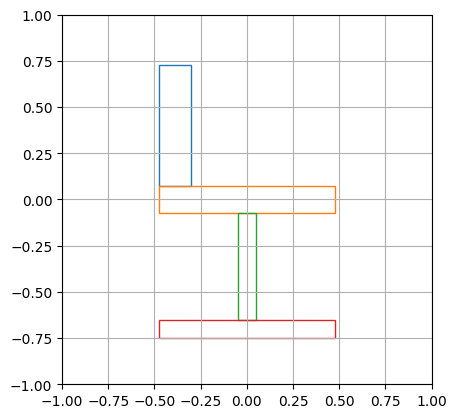

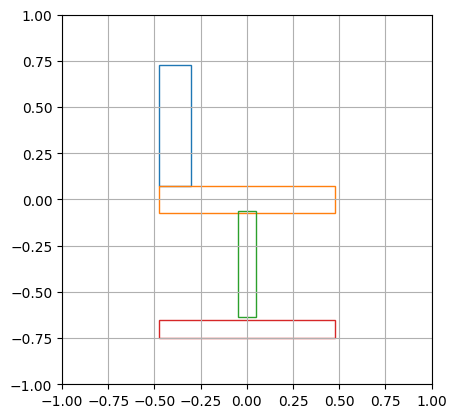

In [24]:

index = 512
print(dataset[index])
print("----------------------")
print(abs_dataset[index])

show_boxes(dataset[index].get_box_list())
show_boxes(abs_dataset[index].get_box_list())
